In [1]:
### IMPORT DES LIBRAIRIES ###
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, roc_auc_score, accuracy_score
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import GridSearchCV
from sklearn.compose import ColumnTransformer
from xgboost import XGBClassifier
from sklearn.linear_model import LogisticRegression
from lightgbm import LGBMClassifier

### EXPLORATION DES DONNEES

In [2]:
### CHARGEMENT DES DONNÉES ###
df = pd.read_csv('bank_data.csv', sep=";", quotechar='"')
df.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  str    
 2   marital         41188 non-null  str    
 3   education       41188 non-null  str    
 4   default         41188 non-null  str    
 5   housing         41188 non-null  str    
 6   loan            41188 non-null  str    
 7   contact         41188 non-null  str    
 8   month           41188 non-null  str    
 9   day_of_week     41188 non-null  str    
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  str    
 15  emp.var.rate    41188 non-null  float64
 16  cons.price.idx  41188 non-null  float64
 17  cons.conf.idx   41188 non-null  float64
 1

In [4]:
df.head().T

,0,1,2,3,4
age,56,57,37,40,56
job,housemaid,services,services,admin.,services
marital,married,married,married,married,married
education,basic.4y,high.school,high.school,basic.6y,high.school
default,no,unknown,no,no,no
housing,no,no,yes,no,no
loan,no,no,no,no,yes
contact,telephone,telephone,telephone,telephone,telephone
month,may,may,may,may,may
day_of_week,mon,mon,mon,mon,mon


In [5]:
### RENOMMAGE DE CERTAINES COLONNES ###
df.columns = (
    df.columns
      .str.replace(".", "_", regex=False)
      .str.replace("-", "_", regex=False)
)
df

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp_var_rate,cons_price_idx,cons_conf_idx,euribor3m,nr_employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
41183,73,retired,married,professional.course,no,yes,no,cellular,nov,fri,...,1,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,yes
41184,46,blue-collar,married,professional.course,no,no,no,cellular,nov,fri,...,1,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,no
41185,56,retired,married,university.degree,no,yes,no,cellular,nov,fri,...,2,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,no
41186,44,technician,married,professional.course,no,no,no,cellular,nov,fri,...,1,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,yes


In [6]:
### GESTION DES VARIABLES CATEGORIELLES ###
df["y"] = df["y"].map({"yes": 1, "no": 0})
binary_cols = ["default", "housing", "loan"]

for col in binary_cols:
    df[col] = df[col].astype("category")

categorical_cols = [
    "job", "marital", "education", "contact",
    "month", "day_of_week", "poutcome"
]

df[categorical_cols] = df[categorical_cols].astype("category")
df = df.replace("unknown", pd.NA)
df["previously_contacted"] = (df["pdays"] != 999).astype(int)
df

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,pdays,previous,poutcome,emp_var_rate,cons_price_idx,cons_conf_idx,euribor3m,nr_employed,y,previously_contacted
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,0,0
1,57,services,married,high.school,NaN,no,no,telephone,may,mon,...,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,0,0
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,0,0
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,0,0
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
41183,73,retired,married,professional.course,no,yes,no,cellular,nov,fri,...,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,1,0
41184,46,blue-collar,married,professional.course,no,no,no,cellular,nov,fri,...,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,0,0
41185,56,retired,married,university.degree,no,yes,no,cellular,nov,fri,...,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,0,0
41186,44,technician,married,professional.course,no,no,no,cellular,nov,fri,...,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,1,0


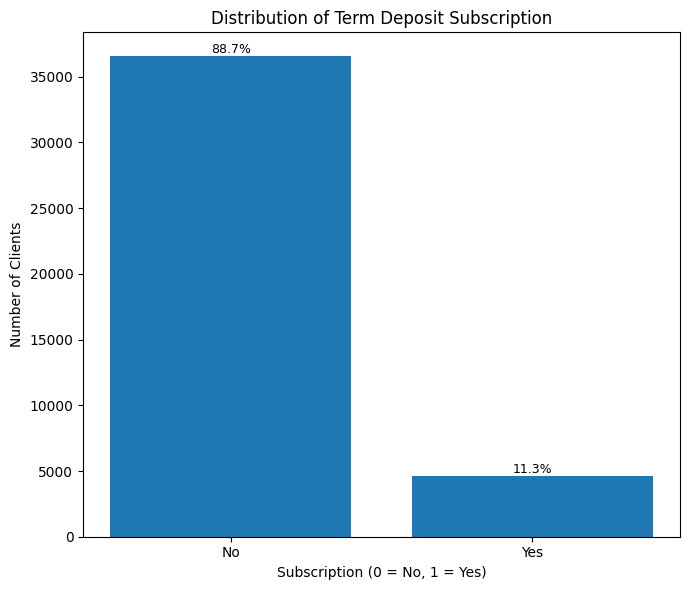

In [7]:
### VISUALISATION DE LA DISTRIBUTION DES TERM DEPOSIT SUBSCRIPTIONS ###
counts = df["y"].value_counts().sort_index()
percentages = counts / counts.sum() * 100
fig, ax = plt.subplots(figsize=(7, 6))
bars = ax.bar(counts.index, counts.values)

ax.set_title("Distribution of Term Deposit Subscription")
ax.set_xlabel("Subscription (0 = No, 1 = Yes)")
ax.set_ylabel("Number of Clients")
ax.set_xticks([0, 1])
ax.set_xticklabels(["No", "Yes"])

# Add percentage labels on top of bars
for bar, pct in zip(bars, percentages):
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f"{pct:.1f}%",
        ha="center",
        va="bottom",
        fontsize=9
    )

plt.tight_layout()
plt.show()


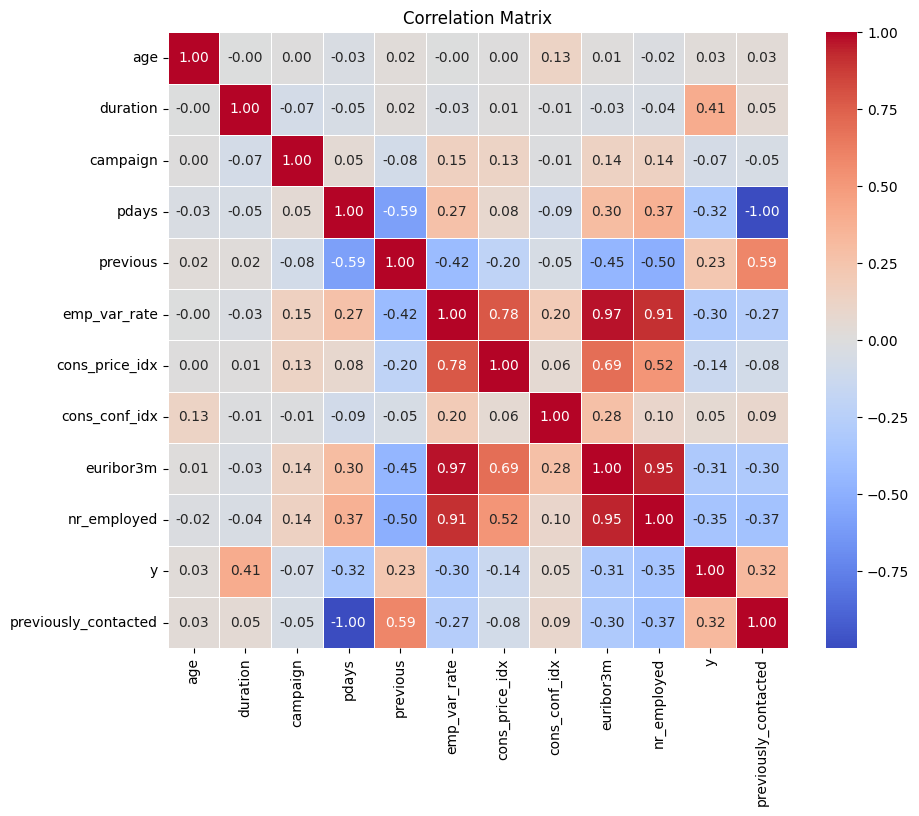

In [8]:
### HEATMAP DE CORRELATION AVEC LA VARIABLE CIBLE ###
numerical_cols = df.select_dtypes(include=["number"]).columns.tolist()
corr_matrix = df[numerical_cols].corr()
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Correlation Matrix")
plt.show()

In [9]:
### SEPARATION DES DONNÉES EN ENTRAINEMENT ET TEST ###
X = df.drop(columns=["y"])
y = df["y"]


X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

## FEATURES ENGINEERING

In [10]:
### ONE HOT ENCODING DES VARIABLES CATEGORIELLES ###
categorical_cols = X.select_dtypes(include=["object", "category"]).columns
numerical_cols = X.select_dtypes(include=["int64", "float64"]).columns

preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols),
        ("num", "passthrough", numerical_cols)
    ]
)

X_train_enc = preprocessor.fit_transform(X_train)
X_test_enc = preprocessor.transform(X_test)


### OVERSAMPLING

In [11]:
# Première technique de suréchantillonnage : SMOTE
from imblearn.over_sampling import SMOTE
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(
    X_train_enc,
    y_train
)

In [12]:
# Deuxième technique de suréchantillonnage : ADASYN
from imblearn.over_sampling import ADASYN
adasyn = ADASYN(random_state=42)
X_train_res_adasyn, y_train_res_adasyn = adasyn.fit_resample(
    X_train_enc,
    y_train
)

In [13]:
### NOUVELLE REPARTITION DES CLASSES APRÈS SURÉCHANTILLONNAGE ###
from collections import Counter
print(Counter(y_train_res))


Counter({0: 29238, 1: 29238})


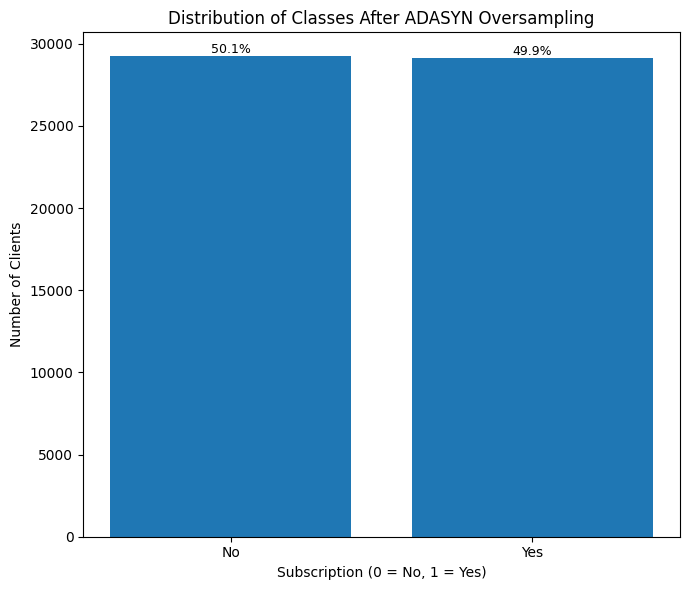

In [14]:
counts = y_train_res_adasyn.value_counts().sort_index()
percentages = counts / counts.sum() * 100
fig, ax = plt.subplots(figsize=(7, 6))
bars = ax.bar(counts.index, counts.values)

ax.set_title("Distribution of Classes After ADASYN Oversampling")
ax.set_xlabel("Subscription (0 = No, 1 = Yes)")
ax.set_ylabel("Number of Clients")
ax.set_xticks([0, 1])
ax.set_xticklabels(["No", "Yes"])

# Add percentage labels on top of bars
for bar, pct in zip(bars, percentages):
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f"{pct:.1f}%",
        ha="center",
        va="bottom",
        fontsize=9
    )

plt.tight_layout()
plt.show()

### First Model : LOGISTIC REGRESSION (Sampling = SMOTE)

In [15]:
### ENTRAINEMENT DU MODELE LOGISTIC REGRESSION ###
logreg_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)
logreg_model.fit(X_train_res, y_train_res)
y_pred_logreg = logreg_model.predict(X_test_enc)
y_proba_logreg = logreg_model.predict_proba(X_test_enc)[:, 1]
print("Logistic Regression Results:")
print(classification_report(y_test, y_pred_logreg))
print("ROC AUC:", roc_auc_score(y_test, y_proba_logreg))

Logistic Regression Results:
              precision    recall  f1-score   support

           0       0.99      0.86      0.92      7310
           1       0.44      0.91      0.60       928

    accuracy                           0.86      8238
   macro avg       0.72      0.88      0.76      8238
weighted avg       0.93      0.86      0.88      8238

ROC AUC: 0.9421023692155289


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


### Second Model : XGBOOST (Sampling = SMOTE)

In [16]:
### ENTRAINEMENT DU MODELE XGBOOST AVEC LES DONNÉES SURÉCHANTILLONNÉES AVEC SMOTE ##
xgb_model = XGBClassifier(
    n_estimators=300,
    max_depth=3,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=42
)

xgb_model.fit(X_train_res, y_train_res)

### EVALUATION DU MODELE XGBOOST ###
y_pred = xgb_model.predict(X_test_enc)
y_proba = xgb_model.predict_proba(X_test_enc)[:, 1]

print(classification_report(y_test, y_pred))
print("ROC AUC:", roc_auc_score(y_test, y_proba))


              precision    recall  f1-score   support

           0       0.95      0.97      0.96      7310
           1       0.69      0.57      0.62       928

    accuracy                           0.92      8238
   macro avg       0.82      0.77      0.79      8238
weighted avg       0.92      0.92      0.92      8238

ROC AUC: 0.9545040450021227


### Second Model : XGBOOST (Sampling = ADASYN)

In [17]:
# training with ADASYN resampled data
xgb_model_adasyn = XGBClassifier(
    n_estimators=300,
    max_depth=3,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=42
)
xgb_model_adasyn.fit(X_train_res_adasyn, y_train_res_adasyn)    
y_pred_adasyn = xgb_model_adasyn.predict(X_test_enc)
y_proba_adasyn = xgb_model_adasyn.predict_proba(X_test_enc)[:, 1]   
print("Results with ADASYN resampling:")
print(classification_report(y_test, y_pred_adasyn))
print("ROC AUC:", roc_auc_score(y_test, y_proba_adasyn))    

Results with ADASYN resampling:
              precision    recall  f1-score   support

           0       0.95      0.97      0.96      7310
           1       0.71      0.59      0.64       928

    accuracy                           0.93      8238
   macro avg       0.83      0.78      0.80      8238
weighted avg       0.92      0.93      0.92      8238

ROC AUC: 0.954786119038634


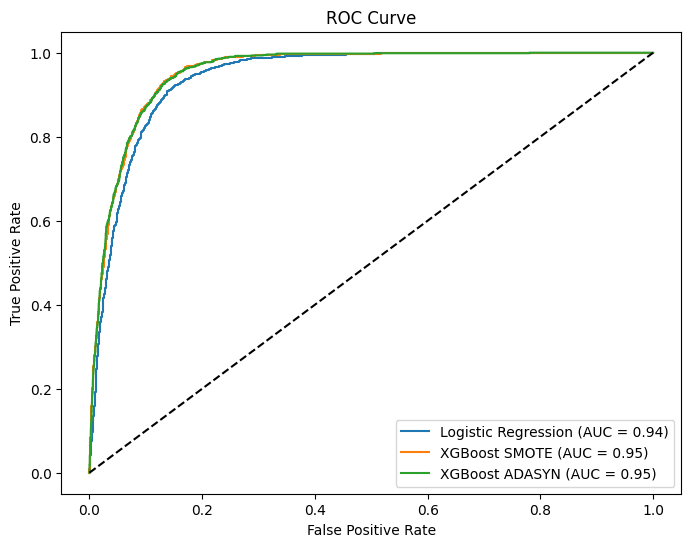

In [18]:
# courbes ROC et PR
from sklearn.metrics import roc_curve, precision_recall_curve
fpr_logreg, tpr_logreg, _ = roc_curve(y_test, y_proba_logreg)
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, y_proba)
fpr_xgb_adasyn, tpr_xgb_adasyn, _ = roc_curve(y_test, y_proba_adasyn)   
plt.figure(figsize=(8, 6))
plt.plot(fpr_logreg, tpr_logreg, label="Logistic Regression (AUC = {:.2f})".format(roc_auc_score(y_test, y_proba_logreg)))
plt.plot(fpr_xgb, tpr_xgb, label="XGBoost SMOTE (AUC = {:.2f})".format(roc_auc_score(y_test, y_proba)))
plt.plot(fpr_xgb_adasyn, tpr_xgb_adasyn, label="XGBoost ADASYN (AUC = {:.2f})".format(roc_auc_score(y_test, y_proba_adasyn)))    
plt.plot([0, 1], [0, 1], "k--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

### GRIDSEARCH

In [19]:
### GRID SEARCH POUR OPTIMISATION DES HYPERPARAMÈTRES DU MODELE XGBOOST ### 

param_grid = {
    "n_estimators": [100, 300, 500],
    "max_depth": [3, 5, 7],
    "learning_rate": [0.01, 0.1, 0.2],
    "subsample": [0.6, 0.8, 1.0],
    "colsample_bytree": [0.6, 0.8, 1.0]
}

dt_grid = GridSearchCV(
    XGBClassifier(random_state=42),
    param_grid,
    cv=5,
    scoring="roc_auc",
    n_jobs=-1
)

dt_grid.fit(X_train_res, y_train_res)
print("Best parameters:", dt_grid.best_params_)
print("Best cross-validation score:", dt_grid.best_score_)

Best parameters: {'colsample_bytree': 0.8, 'learning_rate': 0.1, 'max_depth': 7, 'n_estimators': 100, 'subsample': 0.6}
Best cross-validation score: 0.9927823604468605


In [20]:
### EVALUATION DU MODELE XGBOOST OPTIMISÉ ###
best_xgb = dt_grid.best_estimator_
y_pred_best = best_xgb.predict(X_test_enc)
y_proba_best = best_xgb.predict_proba(X_test_enc)[:, 1]
print(classification_report(y_test, y_pred_best))
print("ROC AUC:", roc_auc_score(y_test, y_proba_best))

              precision    recall  f1-score   support

           0       0.95      0.96      0.96      7310
           1       0.67      0.58      0.62       928

    accuracy                           0.92      8238
   macro avg       0.81      0.77      0.79      8238
weighted avg       0.92      0.92      0.92      8238

ROC AUC: 0.9538750353790273


In [21]:
y_proba_best

array([0.00190632, 0.17953043, 0.3853282 , ..., 0.5345436 , 0.23610948,
       0.00186803], shape=(8238,), dtype=float32)

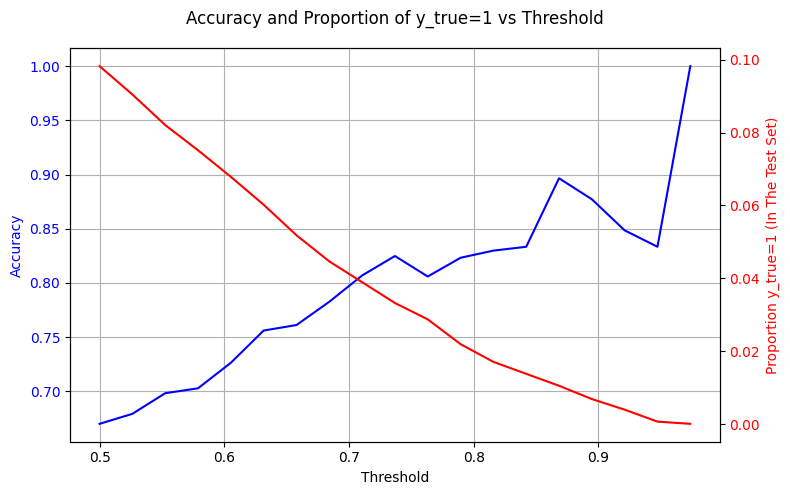

In [22]:
###  EVOLUTION DE L'ACCURACY ET DE LA PROPORTION DE y_true=1 EN FONCTION DU THRESHOLD ###

df = pd.DataFrame({
    "y_true": y_test,
    "y_proba": y_proba_best
})

# Définir les thresholds à tester
thresholds = np.linspace(0.5, 1, 20)
accuracies = []
proportions = []

for t in thresholds:
    # Filtrer le DataFrame selon le threshold
    df_filtered = df[df["y_proba"] > t].copy()
    
    # Si pas de lignes après filtrage, enregistrer NaN
    if len(df_filtered) == 0:
        accuracies.append(np.nan)
        proportions.append(np.nan)
        continue

    # Prédictions
    df_filtered["y_pred"] = np.sign(df_filtered["y_proba"])
    
    # Calcul de l'accuracy
    acc = np.mean(df_filtered["y_true"] == df_filtered["y_pred"])
    accuracies.append(acc)
    
    # Calcul de la proportion de y_true = 1
    prop = len(df_filtered["y_true"] == 1) / len(df["y_true"] == 1)
    proportions.append(prop)

# Tracer sur le même graphique avec deux axes y
fig, ax1 = plt.subplots(figsize=(8,5))

ax1.plot(thresholds, accuracies, color='blue', label='Accuracy')
ax1.set_xlabel("Threshold")
ax1.set_ylabel("Accuracy", color='blue')
ax1.tick_params(axis='y', labelcolor='blue')
ax1.grid(True)

ax2 = ax1.twinx()  # second y-axis
ax2.plot(thresholds, proportions, color='red', label='Proportion y_true=1')
ax2.set_ylabel("Proportion y_true=1 (In The Test Set)", color='red')
ax2.tick_params(axis='y', labelcolor='red')

fig.suptitle("Accuracy and Proportion of y_true=1 vs Threshold")
fig.tight_layout()
plt.show()